# Ödev (En Az 3 Tanesi yapılmalı)

### 1. Tokenizasyon Karşılaştırması (Başlangıç Seviye)

Farklı tokenizer'ları (BPE, WordPiece, SentencePiece) karşılaştırın
Türkçe ve İngilizce metinlerde token sayılarını analiz edin
Nadir kelimeler ve farklı dillerdeki davranışları inceleyin

python, tiktoken, transformers kütüphanelerini kullanarak

,language,tokenizer,token_count,tokens
0,EN,BPE (tiktoken),11,"[2028, 2046, 584, 7863, 1646, 16674, 323, 3952..."
1,EN,WordPiece (BERT),12,"[This, week, we, compared, model, output, ##s,..."
2,EN,SentencePiece (XLM-R),12,"[▁This, ▁week, ▁we, ▁compared, ▁model, ▁output..."
3,TR,BPE (tiktoken),22,"[60908, 6520, 728, 64, 34761, 52691, 1646, 272..."
4,TR,WordPiece (BERT),18,"[Bu, hafta, kamp, ##ta, model, ci, ##kti, ##la..."
5,TR,SentencePiece (XLM-R),18,"[▁Bu, ▁hafta, ▁kamp, ta, ▁model, ▁cik, ti, lar..."
6,RARE,BPE (tiktoken),12,"[19493, 299, 768, 764, 278, 65031, 4037, 2065,..."
7,RARE,WordPiece (BERT),18,"[elect, ##roen, ##ce, ##pha, ##log, ##raphic, ..."
8,RARE,SentencePiece (XLM-R),18,"[▁electro, ence, pha, lo, graphic, ally, ▁to, ..."


tokenizer,BPE (tiktoken),SentencePiece (XLM-R),WordPiece (BERT),best_tokenizer
language,,,,
EN,11,12,12,BPE (tiktoken)
RARE,12,18,18,BPE (tiktoken)
TR,22,18,18,SentencePiece (XLM-R)


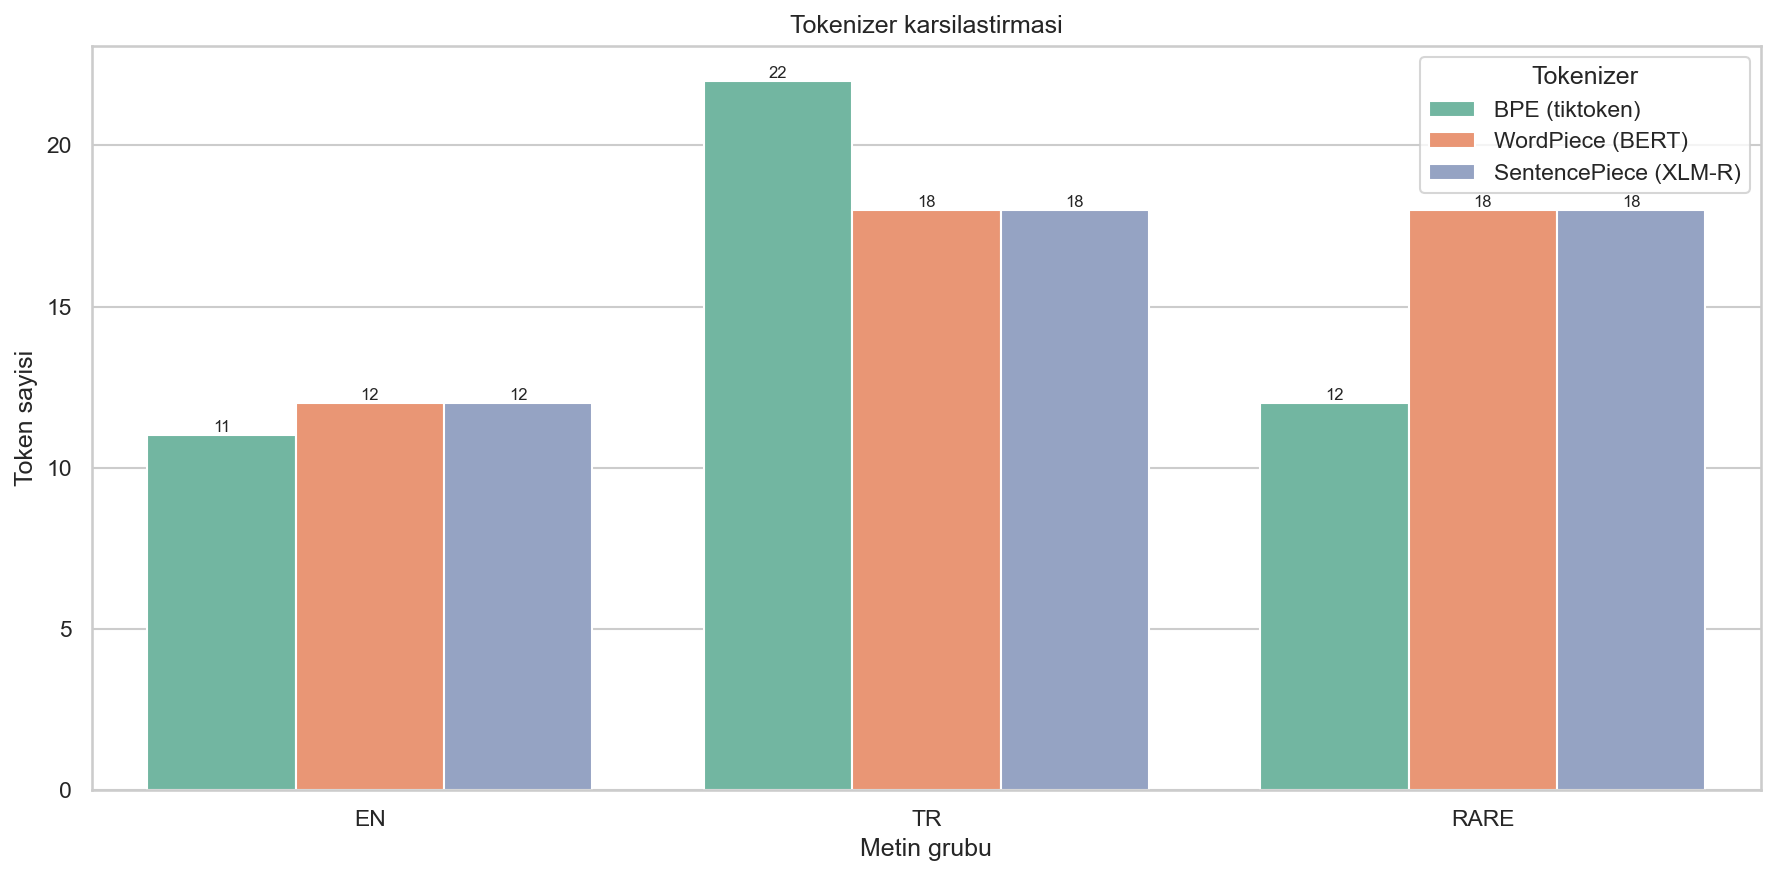

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tiktoken
from transformers import AutoTokenizer

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

test_texts = {
    "EN": "This week we compared model outputs and took short notes.",
    "TR": "Bu hafta kampta model ciktilarini tek tek inceledik ve not aldik.",
    "RARE": "electroencephalographically tokenization positional_encoding low_resource",
}

bpe_tokenizer = tiktoken.get_encoding("cl100k_base")
wordpiece_tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
sentencepiece_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

records = []
for lang, text in test_texts.items():
    bpe_tokens = bpe_tokenizer.encode(text)
    wp_tokens = wordpiece_tokenizer.tokenize(text)
    sp_tokens = sentencepiece_tokenizer.tokenize(text)

    records.extend([
        {"language": lang, "tokenizer": "BPE (tiktoken)", "token_count": len(bpe_tokens), "tokens": bpe_tokens[:15]},
        {"language": lang, "tokenizer": "WordPiece (BERT)", "token_count": len(wp_tokens), "tokens": wp_tokens[:15]},
        {"language": lang, "tokenizer": "SentencePiece (XLM-R)", "token_count": len(sp_tokens), "tokens": sp_tokens[:15]},
    ])

result_df = pd.DataFrame(records)
display(result_df[["language", "tokenizer", "token_count", "tokens"]])

pivot_counts = result_df.pivot(index="language", columns="tokenizer", values="token_count")
pivot_counts["best_tokenizer"] = pivot_counts.idxmin(axis=1)
display(pivot_counts)

plt.figure(figsize=(12, 6), dpi=150)
ax = sns.barplot(data=result_df, x="language", y="token_count", hue="tokenizer", palette="Set2")
ax.set_title("Tokenizer karsilastirmasi")
ax.set_xlabel("Metin grubu")
ax.set_ylabel("Token sayisi")

for bar in ax.patches:
    h = float(bar.get_height())
    if h <= 0:
        continue
    ax.annotate(f"{int(round(h))}", (bar.get_x() + bar.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.legend(title="Tokenizer")
plt.tight_layout()
plt.show()

### 2. Attention Görselleştirme (Orta Seviye)

Basit bir self-attention mekanizması kodlayın (NumPy/PyTorch)
Query, Key, Value matrislerini hesaplayın
Attention skorlarını heatmap olarak görselleştirin
Multi-head attention'ın farklı head'lerini karşılaştırın

Q shape: (6, 16) K shape: (6, 16) V shape: (6, 16)
Attention output shape: (6, 16)


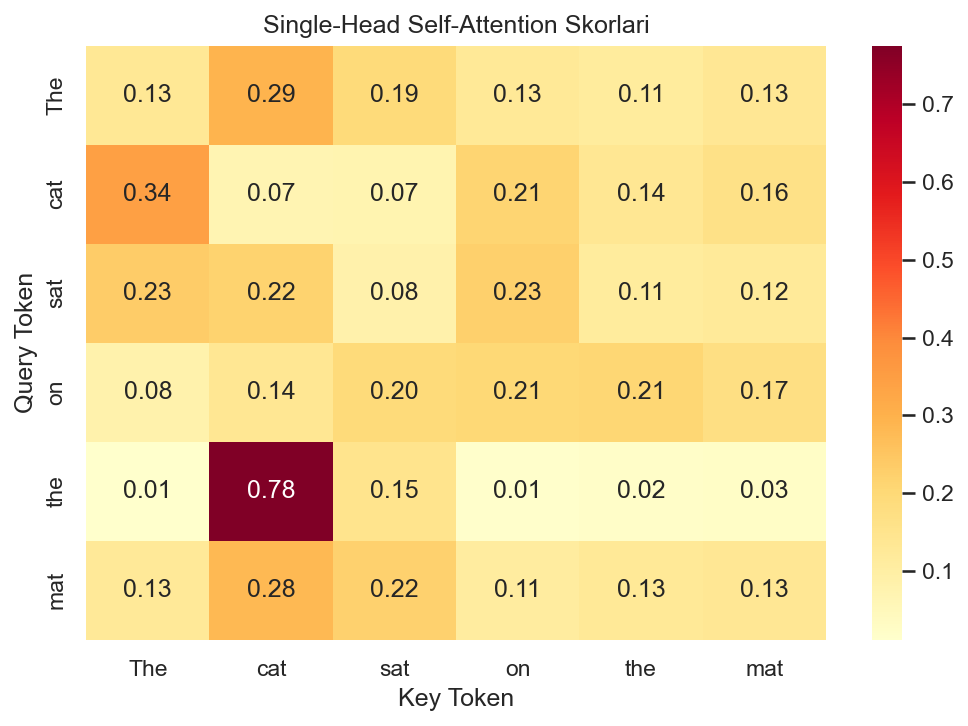

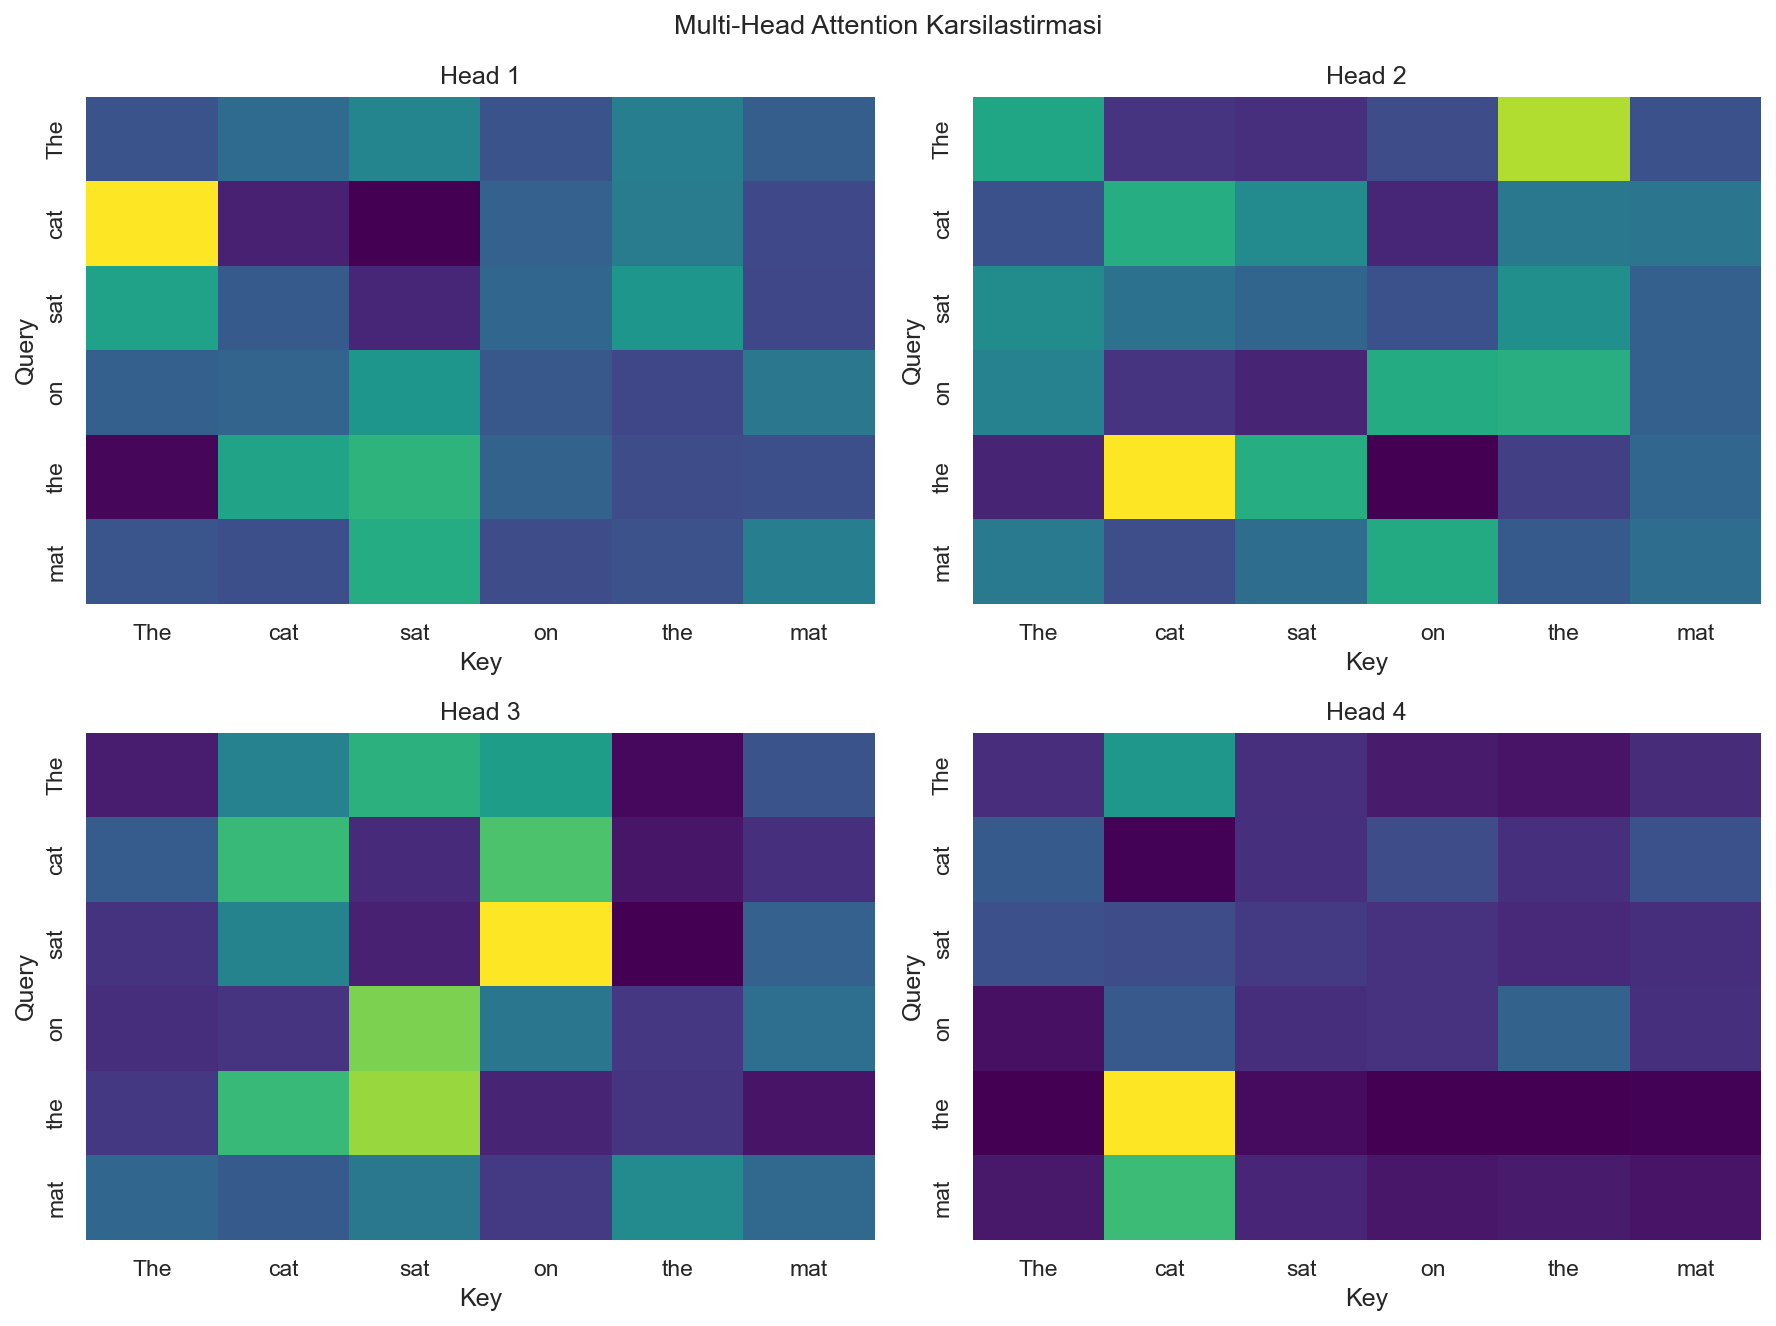

Head 1 ortalama attention entropisi: 1.699
Head 2 ortalama attention entropisi: 1.704
Head 3 ortalama attention entropisi: 1.656
Head 4 ortalama attention entropisi: 1.388


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="notebook")
np.random.seed(42)

sentence = ["The", "cat", "sat", "on", "the", "mat"]
seq_len = len(sentence)
d_model = 16
num_heads = 4
head_dim = d_model // num_heads

X = np.random.randn(seq_len, d_model)
W_Q = np.random.randn(d_model, d_model) * 0.2
W_K = np.random.randn(d_model, d_model) * 0.2
W_V = np.random.randn(d_model, d_model) * 0.2

Q = X @ W_Q
K = X @ W_K
V = X @ W_V

def softmax(x, axis=-1):
    x_shift = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x_shift)
    return e / np.sum(e, axis=axis, keepdims=True)

a_scores = (Q @ K.T) / np.sqrt(d_model)
a_weights = softmax(a_scores, axis=-1)
a_output = a_weights @ V

print("Q shape:", Q.shape, "K shape:", K.shape, "V shape:", V.shape)
print("Attention output shape:", a_output.shape)

plt.figure(figsize=(7, 5), dpi=150)
sns.heatmap(a_weights, xticklabels=sentence, yticklabels=sentence, cmap="YlOrRd", annot=True, fmt=".2f")
plt.title("Single-Head Self-Attention Skorlari")
plt.xlabel("Key Token")
plt.ylabel("Query Token")
plt.tight_layout()
plt.show()

Q_heads = Q.reshape(seq_len, num_heads, head_dim).transpose(1, 0, 2)
K_heads = K.reshape(seq_len, num_heads, head_dim).transpose(1, 0, 2)
V_heads = V.reshape(seq_len, num_heads, head_dim).transpose(1, 0, 2)

head_weights = []
head_outputs = []
for h in range(num_heads):
    s = (Q_heads[h] @ K_heads[h].T) / np.sqrt(head_dim)
    w = softmax(s, axis=-1)
    o = w @ V_heads[h]
    head_weights.append(w)
    head_outputs.append(o)

head_weights = np.array(head_weights)
head_outputs = np.array(head_outputs)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), dpi=150)
for h, ax in enumerate(axes.flatten()):
    sns.heatmap(head_weights[h], xticklabels=sentence, yticklabels=sentence, cmap="viridis", ax=ax, cbar=False)
    ax.set_title(f"Head {h + 1}")
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")

fig.suptitle("Multi-Head Attention Karsilastirmasi", fontsize=13)
plt.tight_layout()
plt.show()

head_entropy = -np.sum(head_weights * np.log(np.clip(head_weights, 1e-12, None)), axis=-1).mean(axis=-1)
for i, ent in enumerate(head_entropy, start=1):
    print(f"Head {i} ortalama attention entropisi: {ent:.3f}")

### 3. Embedding Analizi (Orta Seviye)

Pre-trained bir modelden (örn. BERT, GPT-2) embedding'leri çıkarın
Kelimelerin vektör uzayındaki yakınlıklarını hesaplayın
"king - man + woman ≈ queen" gibi vektör aritmetiği deneyleri yapın
t-SNE veya PCA ile 2D görselleştirme

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 16009.40it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,king,queen,man,woman,prince,princess,apple,orange,dog,cat,python,programming
king,1.000,0.657,0.384,0.316,0.568,0.487,0.327,0.301,0.290,0.297,0.323,0.242
queen,0.657,1.000,0.277,0.428,0.534,0.654,0.361,0.353,0.324,0.364,0.380,0.299
man,0.384,0.277,1.000,0.650,0.341,0.311,0.297,0.274,0.412,0.401,0.303,0.215
woman,0.316,0.428,0.650,1.000,0.302,0.465,0.281,0.286,0.387,0.359,0.377,0.307
prince,0.568,0.534,0.341,0.302,1.000,0.711,0.354,0.400,0.348,0.357,0.403,0.254
princess,0.487,0.654,0.311,0.465,0.711,1.000,0.357,0.408,0.372,0.408,0.485,0.359
apple,0.327,0.361,0.297,0.281,0.354,0.357,1.000,0.491,0.311,0.303,0.443,0.375
orange,0.301,0.353,0.274,0.286,0.400,0.408,0.491,1.000,0.329,0.341,0.449,0.316
dog,0.290,0.324,0.412,0.387,0.348,0.372,0.311,0.329,1.000,0.548,0.410,0.333
cat,0.297,0.364,0.401,0.359,0.357,0.408,0.303,0.341,0.548,1.000,0.409,0.320


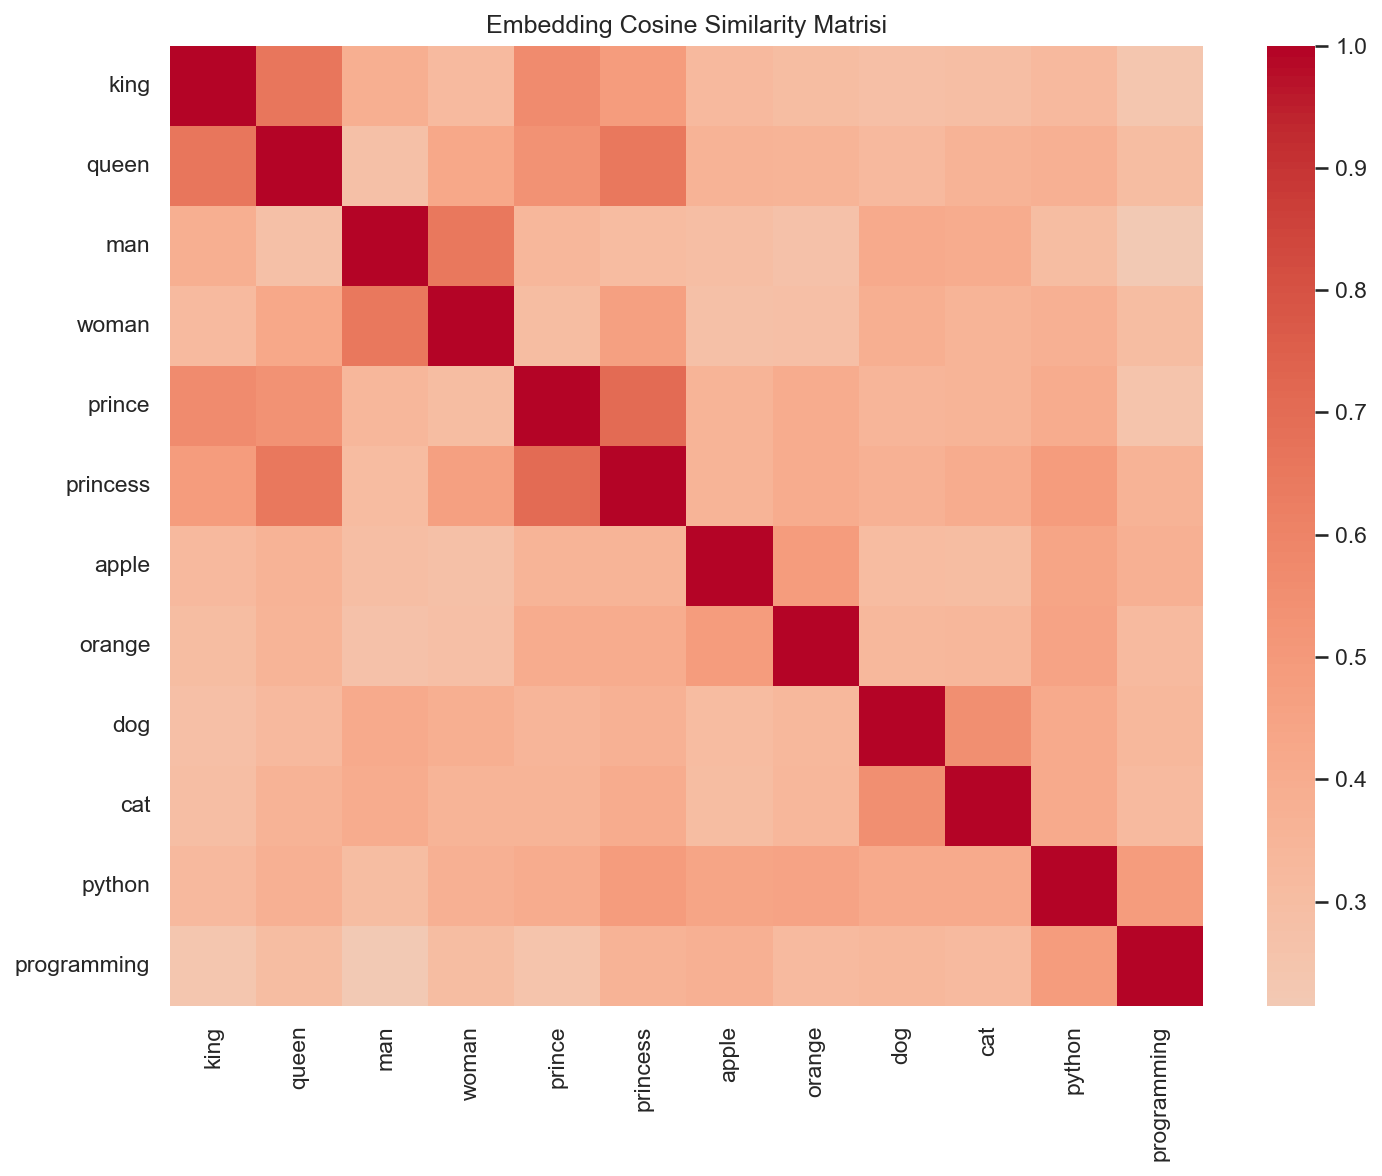

,word,score
0,queen,0.652079
1,princess,0.516690
2,prince,0.432502
3,python,0.321269
4,programming,0.268991


king - man + woman benzeri en yakin kelimeler:
queen        -> 0.6521
princess     -> 0.5167
prince       -> 0.4325
python       -> 0.3213
programming  -> 0.2690


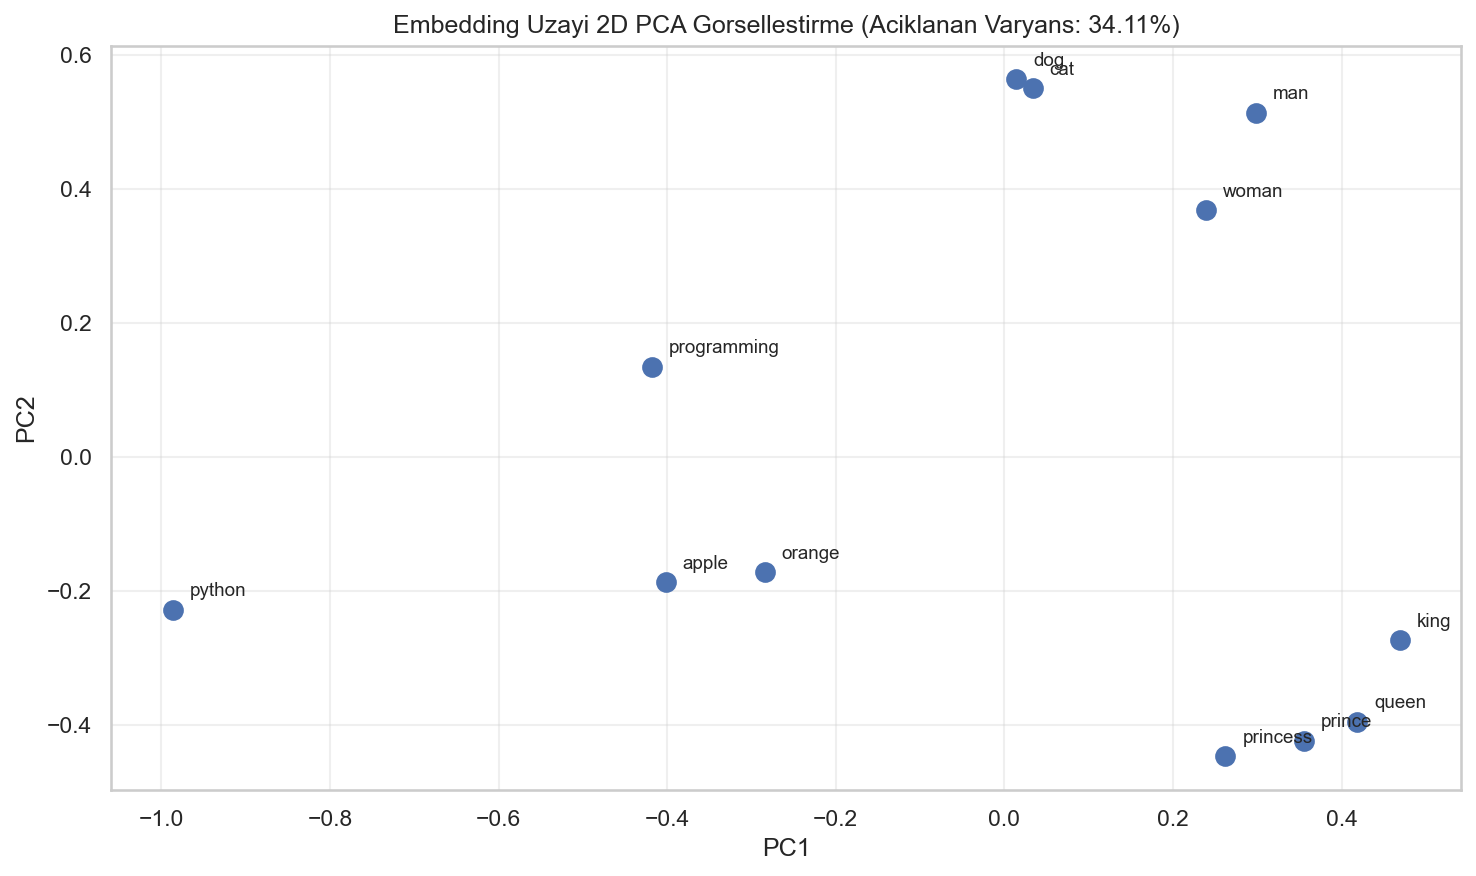

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)
torch.manual_seed(42)

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()

words = [
    "king", "queen", "man", "woman", "prince", "princess",
    "apple", "orange", "dog", "cat", "python", "programming",
]

embedding_layer = model.get_input_embeddings().weight.detach().cpu()
word_vectors = {}

for w in words:
    ids = tokenizer.encode(w, add_special_tokens=False)
    if len(ids) == 0:
        continue
    vec = embedding_layer[ids].mean(dim=0)
    word_vectors[w] = vec.numpy()

valid_words = list(word_vectors.keys())
X = np.vstack([word_vectors[w] for w in valid_words])

norms = np.linalg.norm(X, axis=1, keepdims=True)
Xn = X / np.clip(norms, 1e-12, None)
sim = Xn @ Xn.T

sim_df = pd.DataFrame(sim, index=valid_words, columns=valid_words)
display(sim_df.round(3))

plt.figure(figsize=(10, 8), dpi=150)
sns.heatmap(sim_df, cmap="coolwarm", center=0, annot=False)
plt.title("Embedding Cosine Similarity Matrisi")
plt.tight_layout()
plt.show()

query = word_vectors["king"] - word_vectors["man"] + word_vectors["woman"]
q = query / (np.linalg.norm(query) + 1e-12)

scores = {}
for w in valid_words:
    if w in {"king", "man", "woman"}:
        continue
    v = word_vectors[w]
    v = v / (np.linalg.norm(v) + 1e-12)
    scores[w] = float(q @ v)

nearest = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
nearest_df = pd.DataFrame(nearest, columns=["word", "score"])
display(nearest_df)

print("king - man + woman benzeri en yakin kelimeler:")
for w, s in nearest:
    print(f"{w:12s} -> {s:.4f}")

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)
explained = pca.explained_variance_ratio_.sum()

plt.figure(figsize=(10, 6), dpi=150)
plt.scatter(X2[:, 0], X2[:, 1], s=80)
for i, w in enumerate(valid_words):
    plt.text(X2[i, 0] + 0.02, X2[i, 1] + 0.02, w, fontsize=9)
plt.title(f"Embedding Uzayi 2D PCA Gorsellestirme (Aciklanan Varyans: {explained:.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4. Mini Transformer Bloğu (İleri Seviye)

PyTorch kullanarak basit bir decoder-only transformer bloğu kodlayın
Self-attention + Feed Forward Network + Layer Norm
Küçük bir veri setinde (örn. karakter seviyesi metin) eğitin
Inference sırasında farklı decoding stratejilerini (greedy, top-k, top-p) test edin


Device: cpu
Step   1 | train_loss=3.4588 | val_loss=3.4189
Step  50 | train_loss=2.1522 | val_loss=2.1155
Step 100 | train_loss=1.8192 | val_loss=1.7710
Step 150 | train_loss=1.5134 | val_loss=1.5184
Step 200 | train_loss=1.1808 | val_loss=1.1502
Step 250 | train_loss=0.8341 | val_loss=0.8522


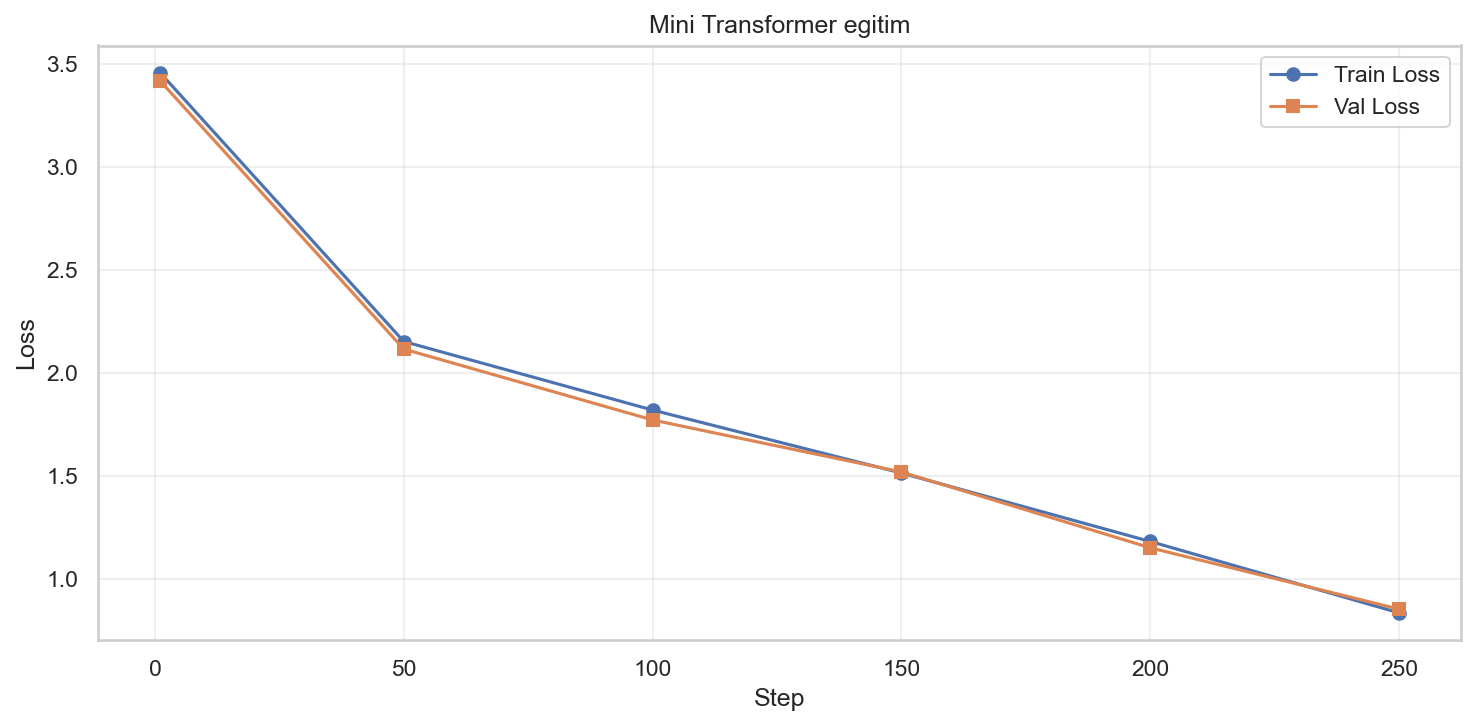

Yaklasik val perplexity: 2.34

Greedy:
 bu hafta a attttention mantigini amanlanlak binini sinlanlamamanimamani amark icikaklicikarkline birkark te be deli urde belegiri

Top-k:
 bu hafta attenti k a aci cinenti si mac cintintikapti mazi ci . barklimati bi acinilin azimalinesinli dergin de cikekti ki dek bi

Top-p:
 bu hafta attentioni anla mamanic bafalantininiginlan aninlamamanlak bini ac banili in andamakacikafaklinimemelen ikli aptimenemel
Model kaydedildi


In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_text = (
    "bu hafta attention mantigini anlamak icin birkac farkli deneme yaptim"
    "bazi denemelerde model cok iyi topladi, bazilarinda gereksiz tekrar uretti"
    "top k ve top p ayarlarini degistirince cikti kalitesi belirgin sekilde degisti"
) * 20

chars = sorted(list(set(data_text)))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encoded = torch.tensor([stoi[c] for c in data_text], dtype=torch.long)
split = int(0.9 * len(encoded))
train_data = encoded[:split]
val_data = encoded[split:]

block_size = 64
batch_size = 32
n_embed = 64
n_heads = 4
ff_dim = 256
n_iters = 250
eval_interval = 50
lr = 1e-3

def get_batch(split_name):
    src = train_data if split_name == "train" else val_data
    ix = torch.randint(low=0, high=len(src) - block_size - 1, size=(batch_size,))
    x = torch.stack([src[i:i + block_size] for i in ix])
    y = torch.stack([src[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embed, n_heads, block_size):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = n_embed // n_heads
        self.qkv = nn.Linear(n_embed, 3 * n_embed)
        self.proj = nn.Linear(n_embed, n_embed)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:T, :T] == 0, float("-inf"))
        w = F.softmax(att, dim=-1)

        out = w @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)

class TransformerBlock(nn.Module):
    def __init__(self, n_embed, n_heads, ff_dim, block_size):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embed)
        self.attn = CausalSelfAttention(n_embed, n_heads, block_size)
        self.ln2 = nn.LayerNorm(n_embed)
        self.ff = nn.Sequential(
            nn.Linear(n_embed, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, n_embed),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class MiniDecoderLM(nn.Module):
    def __init__(self, vocab_size, n_embed, n_heads, ff_dim, block_size):
        super().__init__()
        self.block_size = block_size
        self.token_emb = nn.Embedding(vocab_size, n_embed)
        self.pos_emb = nn.Embedding(block_size, n_embed)
        self.block = TransformerBlock(n_embed, n_heads, ff_dim, block_size)
        self.ln_f = nn.LayerNorm(n_embed)
        self.head = nn.Linear(n_embed, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = tok + pos
        x = self.block(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

model = MiniDecoderLM(vocab_size, n_embed, n_heads, ff_dim, block_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses, val_losses = [], []

for step in range(1, n_iters + 1):
    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if step % eval_interval == 0 or step == 1:
        model.eval()
        with torch.no_grad():
            vx, vy = get_batch("val")
            _, vloss = model(vx, vy)
        model.train()

        train_losses.append((step, float(loss.item())))
        val_losses.append((step, float(vloss.item())))
        print(f"Step {step:3d} | train_loss={loss.item():.4f} | val_loss={vloss.item():.4f}")

def sample_next_token(logits, strategy="greedy", top_k=10, top_p=0.9, temperature=1.0):
    logits = logits / max(temperature, 1e-6)
    probs = F.softmax(logits, dim=-1)

    if strategy == "greedy":
        return torch.argmax(probs, dim=-1, keepdim=True)

    if strategy == "top_k":
        k = min(top_k, probs.shape[-1])
        values, indices = torch.topk(probs, k=k, dim=-1)
        values = values / values.sum(dim=-1, keepdim=True)
        sampled = torch.multinomial(values, num_samples=1)
        return indices.gather(-1, sampled)

    if strategy == "top_p":
        sorted_probs, sorted_idx = torch.sort(probs, descending=True)
        cumulative = torch.cumsum(sorted_probs, dim=-1)
        mask = cumulative > top_p
        mask[..., 1:] = mask[..., :-1].clone()
        mask[..., 0] = False
        sorted_probs = sorted_probs.masked_fill(mask, 0.0)
        sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
        sampled = torch.multinomial(sorted_probs, num_samples=1)
        return sorted_idx.gather(-1, sampled)

    raise ValueError("strategy must be one of: greedy, top_k, top_p")

@torch.no_grad()
def generate(model, seed_text, max_new_tokens=120, strategy="greedy", top_k=10, top_p=0.9, temperature=1.0):
    model.eval()
    idx = torch.tensor([[stoi.get(c, 0) for c in seed_text]], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, _ = model(idx_cond)
        last = logits[:, -1, :]
        next_token = sample_next_token(
            last, strategy=strategy, top_k=top_k, top_p=top_p, temperature=temperature
        )
        idx = torch.cat([idx, next_token], dim=1)

    decoded = "".join(itos[int(i)] for i in idx[0].cpu().tolist())
    return decoded

plt.figure(figsize=(10, 5), dpi=150)
plt.plot([s for s, _ in train_losses], [l for _, l in train_losses], marker="o", label="Train Loss")
plt.plot([s for s, _ in val_losses], [l for _, l in val_losses], marker="s", label="Val Loss")
plt.title("Mini Transformer egitim")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

last_val_loss = val_losses[-1][1]
print(f"Yaklasik val perplexity: {math.exp(last_val_loss):.2f}")

seed = "bu hafta "
print("\nGreedy:\n", generate(model, seed, strategy="greedy", temperature=0.8))
print("\nTop-k:\n", generate(model, seed, strategy="top_k", top_k=10, temperature=1.0))
print("\nTop-p:\n", generate(model, seed, strategy="top_p", top_p=0.9, temperature=1.0))

torch.save(model.state_dict(), "mini_transformer_checkpoint.pt")
print("Model kaydedildi")

### 5. Inference Stratejileri Karşılaştırması (Orta Seviye)

Hugging Face transformers ile bir model yükleyin
Aynı prompt için farklı parametrelerle çıktı üretin:

Temperature: 0.1, 0.7, 1.5

Top-k: 10, 50

Top-p: 0.9, 0.95


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 8317.04it/s]


,temperature,top_k,top_p,diversity_score,output
0,0.1,10,0.90,0.933333,Bugun model ciktilarini denerken en cok dikkat...
1,0.1,10,0.95,0.965517,Bugun model ciktilarini denerken en cok dikkat...
2,0.1,50,0.90,0.750000,Bugun model ciktilarini denerken en cok dikkat...
3,0.1,50,0.95,1.000000,Bugun model ciktilarini denerken en cok dikkat...
4,0.7,10,0.90,0.962963,Bugun model ciktilarini denerken en cok dikkat...
5,0.7,10,0.95,1.000000,Bugun model ciktilarini denerken en cok dikkat...
6,0.7,50,0.90,1.000000,Bugun model ciktilarini denerken en cok dikkat...
7,0.7,50,0.95,1.000000,Bugun model ciktilarini denerken en cok dikkat...
8,1.5,10,0.90,0.966667,Bugun model ciktilarini denerken en cok dikkat...
9,1.5,10,0.95,1.000000,Bugun model ciktilarini denerken en cok dikkat...


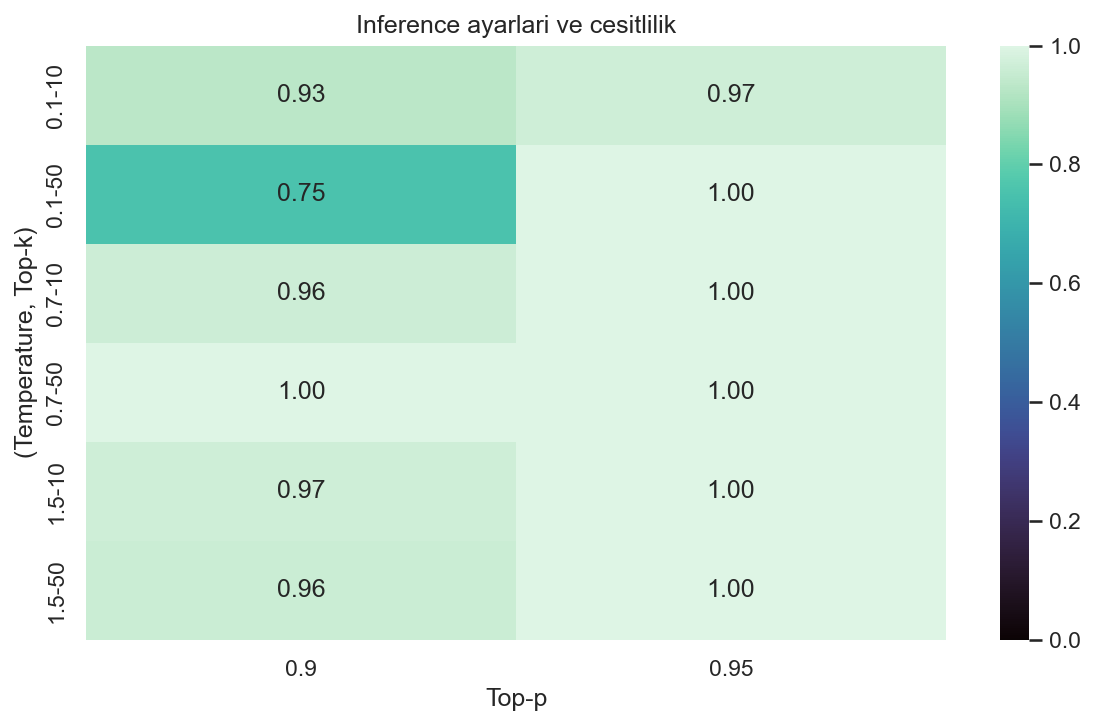

En cesitli sonuc:
T=0.1, top_k=50, top_p=0.95, score=1.00


In [31]:
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

torch.manual_seed(42)

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

prompt = "Bugun model ciktilarini denerken en cok dikkatimi ceken sey"

temps = [0.1, 0.7, 1.5]
ks = [10, 50]
ps = [0.9, 0.95]

rows = []

for t, k, p in itertools.product(temps, ks, ps):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=True,
            temperature=t,
            top_k=k,
            top_p=p,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    text = tokenizer.decode(out_ids[0], skip_special_tokens=True)
    gen = text[len(prompt):]
    toks = gen.split()
    diversity = len(set(toks)) / max(len(toks), 1)

    rows.append(
        {
            "temperature": t,
            "top_k": k,
            "top_p": p,
            "diversity_score": diversity,
            "output": text,
        }
    )

df = pd.DataFrame(rows).sort_values(["temperature", "top_k", "top_p"]).reset_index(drop=True)
display(df[["temperature", "top_k", "top_p", "diversity_score", "output"]])

heat = df.pivot_table(
    index=["temperature", "top_k"],
    columns="top_p",
    values="diversity_score",
    aggfunc="mean",
)

plt.figure(figsize=(8, 5), dpi=150)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="mako", vmin=0.0, vmax=1.0)
plt.title("Inference ayarlari ve cesitlilik")
plt.xlabel("Top-p")
plt.ylabel("(Temperature, Top-k)")
plt.tight_layout()
plt.show()

best = df.loc[df["diversity_score"].idxmax()]
print("En cesitli sonuc:")
print(
    f"T={best['temperature']}, top_k={int(best['top_k'])}, "
    f"top_p={best['top_p']}, score={best['diversity_score']:.2f}"
)